In [1]:
pip install scikit_posthocs

Note: you may need to restart the kernel to use updated packages.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import poisson, chi2
from scipy import stats

In [24]:
df_treatment = pd.read_csv("data_csvs/Data_TreatmentTimes.csv")
df_treatment.info()
df_treatment.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18565 entries, 0 to 18564
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     18565 non-null  int64  
 1   Treatment Time (Days)  18565 non-null  float64
 2   Specialty              18565 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 435.2+ KB


,ID,Treatment Time (Days),Specialty
0,0,4.640229,Ortho
1,1,0.770322,Renal
2,2,1.911212,Card
3,3,4.199311,Respi
4,4,2.527663,Gastro_Endo


In [25]:
df_treatment.columns.tolist()


['ID', 'Treatment Time (Days)', 'Specialty']

In [28]:
#reindex the dataframe
df_treatment = df_treatment.rename(columns={"Treatment Time (Days)": "TreatmentTime"})
# bro why is this not working
#df_treatment = df_treatment.set_index('ID')
df_treatment

,TreatmentTime,Specialty
ID,,
0,4.640229,Ortho
1,0.770322,Renal
2,1.911212,Card
3,4.199311,Respi
4,2.527663,Gastro_Endo
...,...,...
18560,3.715383,Respi
18561,2.305584,Respi
18562,7.595695,Gastro_Endo


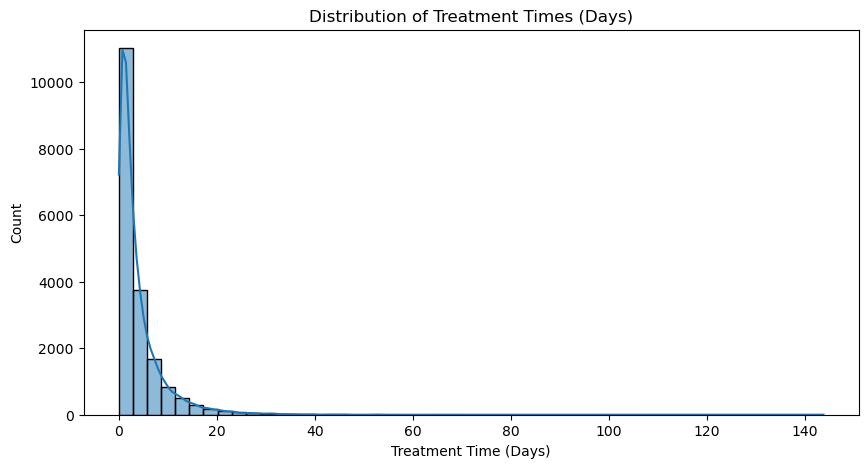

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_treatment["TreatmentTime"], kde=True, bins=50)
plt.title("Distribution of Treatment Times (Days)")
plt.xlabel("Treatment Time (Days)")
plt.ylabel("Count")
plt.show()


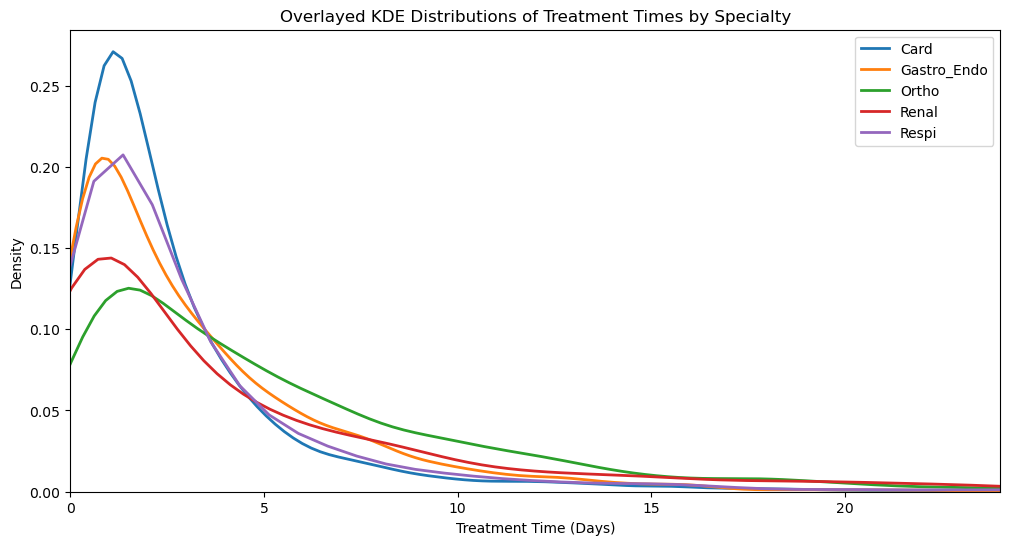

In [35]:
plt.figure(figsize=(12,6))

for spec, df in df_treatment.groupby("Specialty"):
    sns.kdeplot(df["TreatmentTime"], label=spec, linewidth=2)

plt.title("Overlayed KDE Distributions of Treatment Times by Specialty")
plt.xlabel("Treatment Time (Days)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, df_treatment["TreatmentTime"].quantile(0.99))  # cut extreme outliers
plt.show()

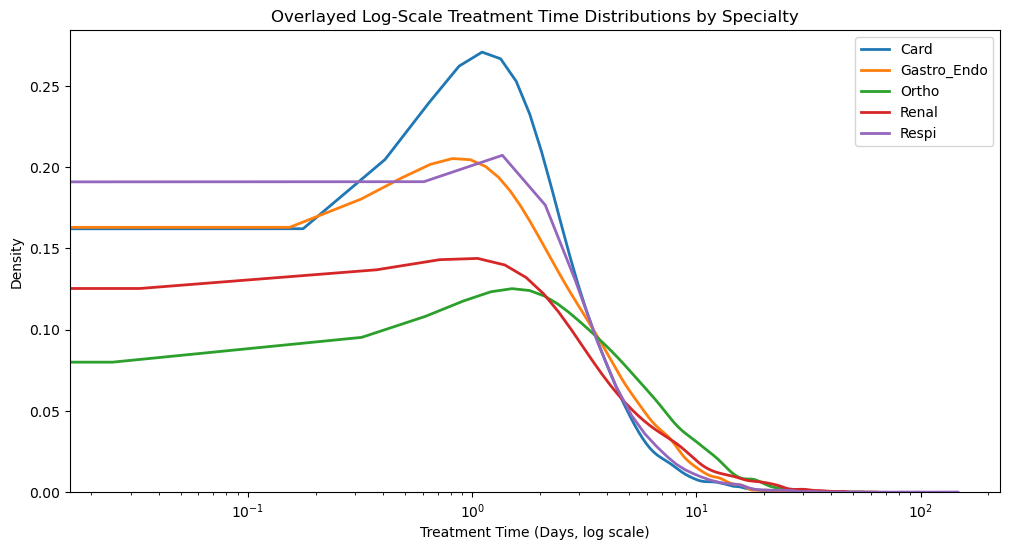

In [34]:
plt.figure(figsize=(12,6))

for spec, df in df_treatment.groupby("Specialty"):
    sns.kdeplot(df["TreatmentTime"], label=spec, linewidth=2)

plt.xscale("log")
plt.title("Overlayed Log-Scale Treatment Time Distributions by Specialty")
plt.xlabel("Treatment Time (Days, log scale)")
plt.ylabel("Density")
plt.legend()
plt.show()



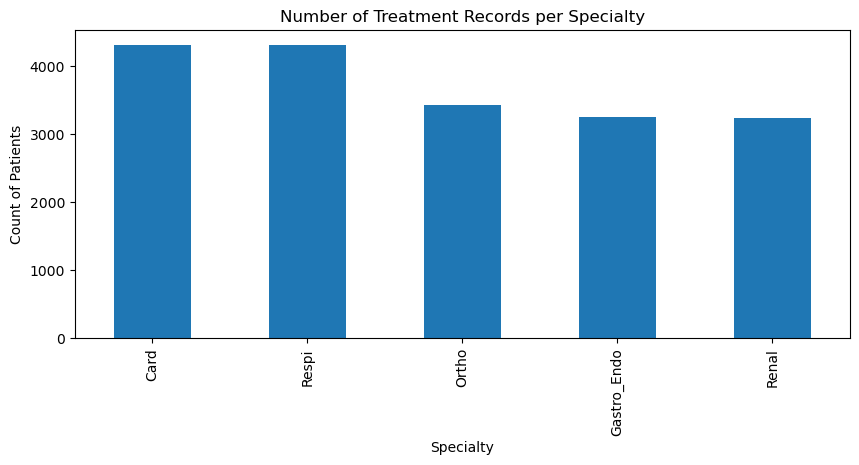

In [31]:
plt.figure(figsize=(10,4))
df_treatment["Specialty"].value_counts().plot(kind="bar")
plt.ylabel("Count of Patients")
plt.title("Number of Treatment Records per Specialty")
plt.show()


## Statistical tests to measure differences between specialties

### Do treatment times differ significantly between specialties?

- to determine if treatment-time data suggests that different specialties follow different underlying treatment-time distributions, we first apply the kruskal-wallis test
- k-w test is nonparametric and compares the central tendencies of multiple groups
- this is good for this use case since it's not applicable with ANOVA (right-skewed, not uniform)
- more than 2 groups, so we shouldn't be using Mann-Whitney U
- also handles unequal group sizes naturally

### Null hypothesis
H0: All specialties have treatment-time distributions drawn from the same underlying population.
- if our p-value is below 0.05, then we reject the null hypothesis and conclude that at least one specialty differs signifcantly form the others in its treatment-time distribution
- looking visually at them, we don't really see that, so I don't expect to reject the H0 (but i dunno)

### Specialities differing from one another
The Kruskal-Wallis test indicates that differences exist, but it does not identify which specialities differ, so we need the Dunn's test instead.
Dunn's test:
- standard pairwise follow up to Kruskal-Wallis; they are frequently used together
- 10 comparisons for 5 classes, since we want to compare each class against every other class



In [37]:
def fit_distributions_by_specialty(df, time_col="TreatmentTime", group_col="Specialty"):
    """
    Fits several candidate distributions to treatment times for each specialty.
    Returns a DataFrame with AIC/BIC and best distribution per specialty.
    """
    candidate_dists = {
        "expon": stats.expon,
        "lognorm": stats.lognorm,
        "gamma": stats.gamma,
        "weibull": stats.weibull_min,
    }

    results = []

    for spec, group in df.groupby(group_col):
        data = group[time_col].values
        # Keep strictly positive times for these distributions
        data = data[data > 0]
        n = len(data)
        if n == 0:
            continue

        for name, dist in candidate_dists.items():
            try:
                params = dist.fit(data)  # MLE fit
                loglik = np.sum(dist.logpdf(data, *params))
                k = len(params)
                aic = 2 * k - 2 * loglik
                bic = k * np.log(n) - 2 * loglik

                results.append({
                    "Specialty": spec,
                    "Distribution": name,
                    "Params": params,
                    "LogLik": loglik,
                    "AIC": aic,
                    "BIC": bic,
                    "N": n,
                })
            except Exception as e:
                # If a fit fails (rare), just skip that combination
                print(f"Fit failed for {spec}, {name}: {e}")
                continue

    results_df = pd.DataFrame(results)

    # Get the best distribution per specialty by AIC (lower is better)
    best_aic = results_df.loc[results_df.groupby("Specialty")["AIC"].idxmin()].reset_index(drop=True)

    return results_df, best_aic


In [38]:
all_fits, best_fits = fit_distributions_by_specialty(df_treatment)

print("All fits (first few rows):")
display(all_fits.head())

print("\nBest distribution per specialty (by AIC):")
display(best_fits[["Specialty", "Distribution", "AIC", "BIC", "N"]])


All fits (first few rows):


,Specialty,Distribution,Params,LogLik,AIC,BIC,N
0,Card,expon,"(0.059281579849131, 2.8257131896865513)",-8809.485370,17622.970741,17635.713225,4321
1,Card,lognorm,"(0.9935142318274037, 0.008114213350338306, 1.7...",-8555.528709,17117.057418,17136.171144,4321
2,Card,gamma,"(0.6086153774025864, 0.059281579849130996, 5.5...",-9230.300995,18466.601991,18485.715717,4321
3,Card,weibull,"(0.9778584972444675, 0.059281579849130996, 2.8...",-8809.095235,17624.190470,17643.304196,4321
4,Gastro_Endo,expon,"(0.000680616, 3.3745058525433578)",-7211.673919,14427.347838,14439.523119,3254



Best distribution per specialty (by AIC):


,Specialty,Distribution,AIC,BIC,N
0,Card,lognorm,17117.057418,17136.171144,4321
1,Gastro_Endo,gamma,14355.531605,14373.794526,3254
2,Ortho,expon,18519.785200,18532.062914,3425
3,Renal,gamma,15372.338560,15390.592248,3244
4,Respi,lognorm,18025.001520,18044.115247,4321


In [39]:
def plot_best_fit_for_specialty(df, best_fits_df, specialty, time_col="TreatmentTime"):
    """
    Plots empirical histogram and best-fit PDF for a given specialty.
    """
    row = best_fits_df[best_fits_df["Specialty"] == specialty]
    if row.empty:
        print(f"No fit found for specialty '{specialty}'.")
        return

    dist_name = row["Distribution"].iloc[0]
    params = row["Params"].iloc[0]

    candidate_dists = {
        "expon": stats.expon,
        "lognorm": stats.lognorm,
        "gamma": stats.gamma,
        "weibull": stats.weibull_min,
    }
    dist = candidate_dists[dist_name]

    data = df.loc[df["Specialty"] == specialty, time_col].values
    data = data[data > 0]

    # x-grid for PDF
    x = np.linspace(0, np.quantile(data, 0.99), 500)

    plt.figure(figsize=(10, 5))
    # Empirical histogram
    sns.histplot(data, bins=50, stat="density", alpha=0.3, label="Empirical")
    # Fitted PDF
    plt.plot(x, dist.pdf(x, *params), linewidth=2, label=f"Fitted {dist_name}")

    plt.title(f"Best-fit distribution for {specialty}")
    plt.xlabel("Treatment Time (Days)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


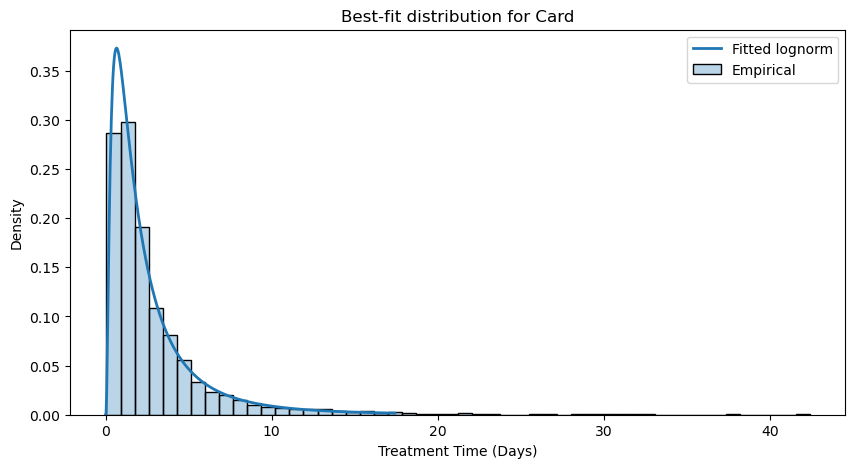

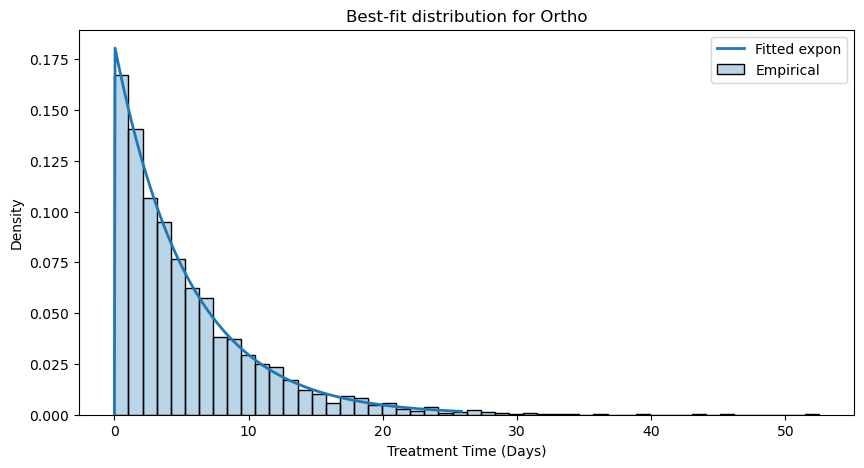

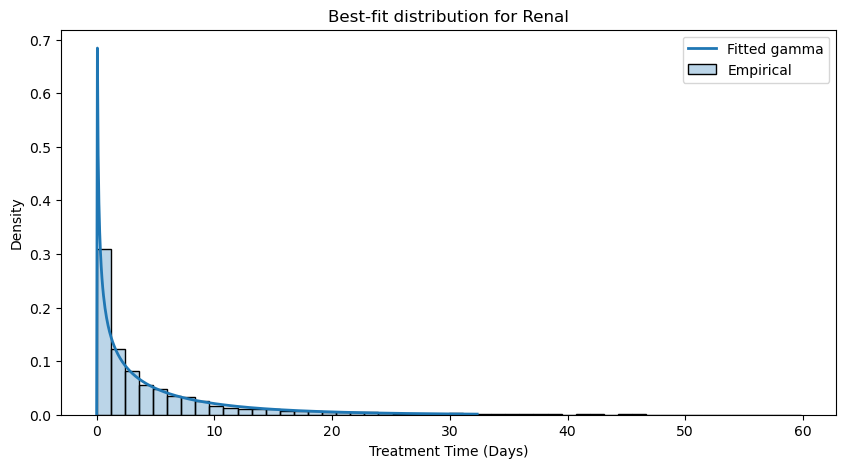

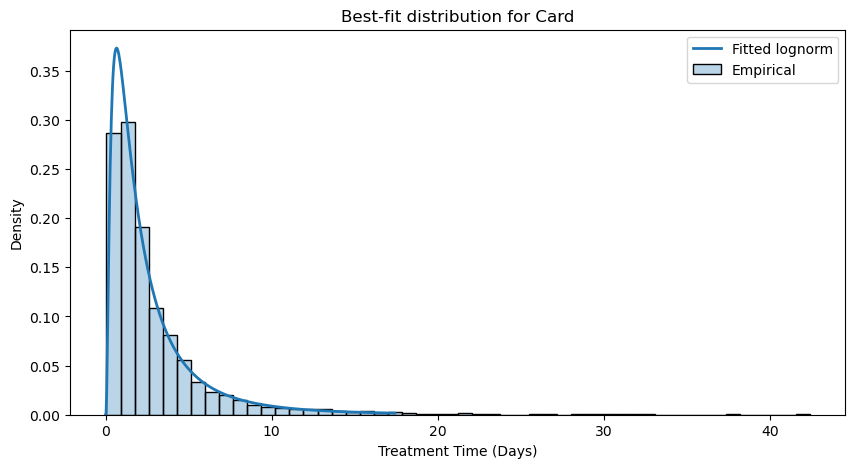

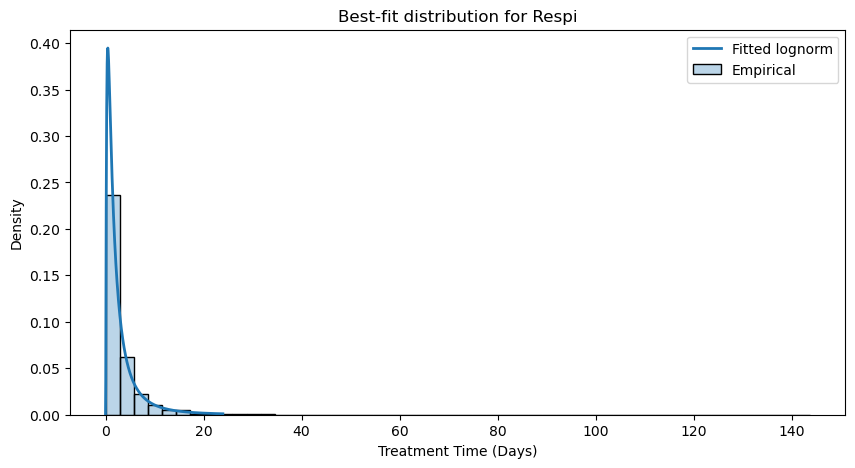

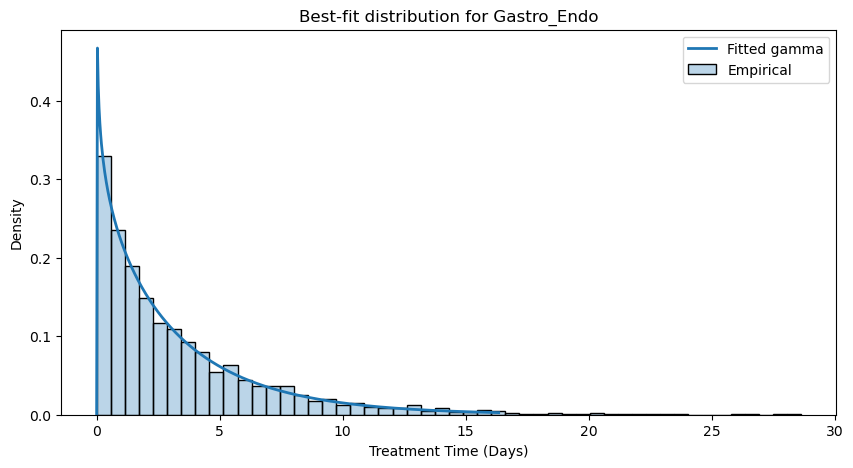

In [40]:
# Example: plot for Cardiology
plot_best_fit_for_specialty(df_treatment, best_fits, "Card")

# You can loop over all specialties:
for spec in df_treatment["Specialty"].unique():
    plot_best_fit_for_specialty(df_treatment, best_fits, spec)


## Goodness of Fit Test

### Q-Q plots
quantile-quantile plots allows to compare the empircal data (the actual data) to the theoretical quantiles predicted by the fitted distribution.
this is useful because:
- it shows deviations in the mean, variance, skewness, and tail behaviour
- highlights mismatches that are harder to see visually
- validates whether or not the fitted dist'n we chose actually fits the data

In [42]:
candidate_dists = {
    "expon": stats.expon,
    "lognorm": stats.lognorm,
    "gamma": stats.gamma,
    "weibull": stats.weibull_min,
}

def qq_plots_all_distributions(df, specialty, time_col="TreatmentTime"):
    data = df.loc[df["Specialty"] == specialty, time_col].values
    data = data[data > 0]   # distributions require positive values

    plt.figure(figsize=(12, 12))
    plot_index = 1

    for name, dist in candidate_dists.items():
        params = dist.fit(data)

        plt.subplot(2, 2, plot_index)
        stats.probplot(data, dist=dist, sparams=params, plot=plt)

        plt.title(f"{specialty} — Q-Q plot ({name})")
        plot_index += 1

    plt.tight_layout()
    plt.show()


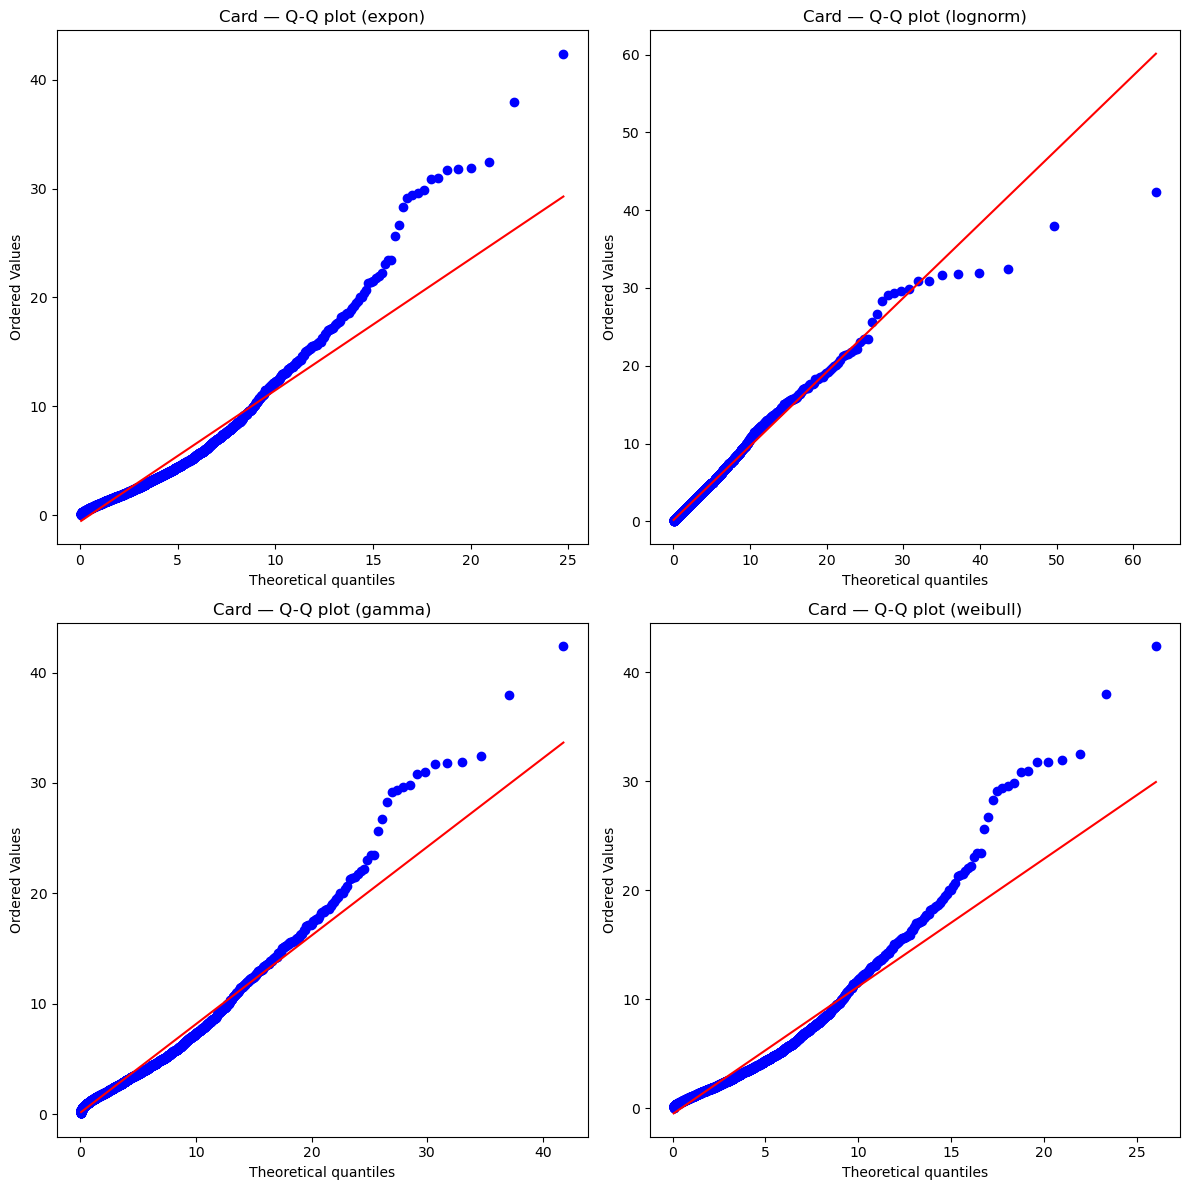

In [43]:
qq_plots_all_distributions(df_treatment, "Card")


In [44]:
def qq_plot_best_fit(df, best_fits_df, specialty, time_col="TreatmentTime"):
    row = best_fits_df[best_fits_df["Specialty"] == specialty]

    if row.empty:
        print(f"No best fit found for {specialty}")
        return
    
    dist_name = row["Distribution"].iloc[0]
    params = row["Params"].iloc[0]

    dist = candidate_dists[dist_name]
    data = df.loc[df["Specialty"] == specialty, time_col].values
    data = data[data > 0]

    plt.figure(figsize=(6, 6))
    stats.probplot(data, dist=dist, sparams=params, plot=plt)
    plt.title(f"{specialty} — Q-Q plot (best fit: {dist_name})")
    plt.show()


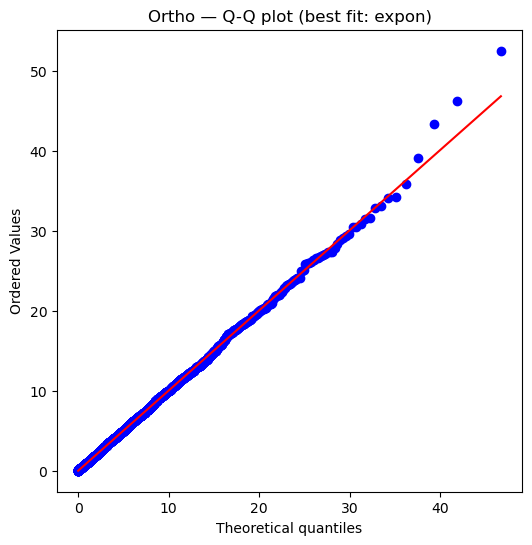

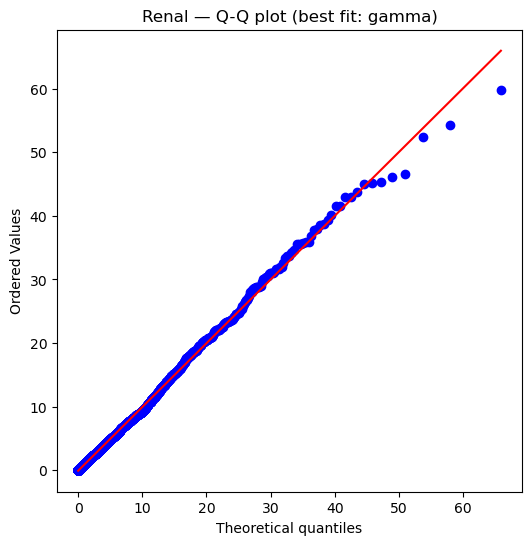

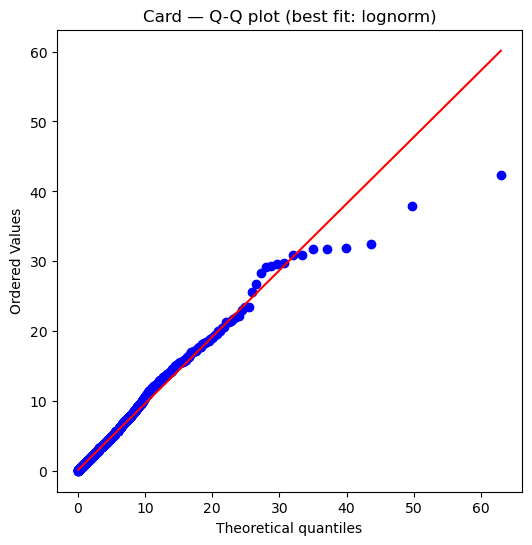

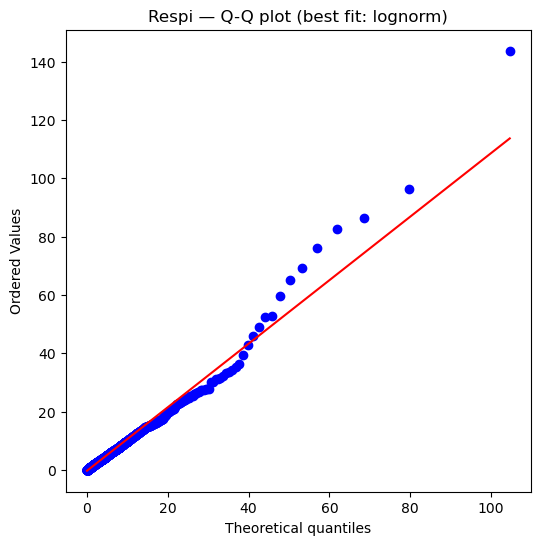

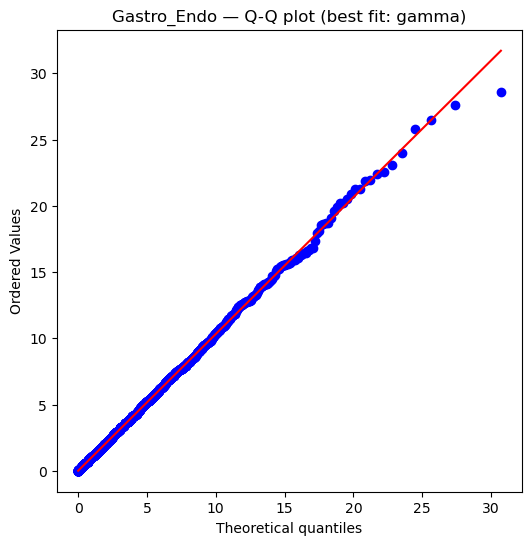

In [46]:
for spec in df_treatment["Specialty"].unique():
    qq_plot_best_fit(df_treatment, best_fits, spec)
